In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib

# Set tema visualisasi agar rapi
sns.set_theme(style="whitegrid")

# 1. Load Data
df = pd.read_csv('data_penumpang_harian.csv')
df = df[df['jenis_moda'] == 'TRANSJAKARTA'].reset_index(drop=True)

# 2. Preprocessing & Cleaning
df['jumlah_penumpang_per_hari'] = df['jumlah_penumpang_per_hari'].astype(str).str.replace(' ', '')
df['jumlah_penumpang_per_hari'] = pd.to_numeric(df['jumlah_penumpang_per_hari'], errors='coerce')
df = df.dropna(subset=['jumlah_penumpang_per_hari']).reset_index(drop=True)

# 3. Rescaling ke skala MikroTrans
df['jumlah_penumpang_per_hari'] = (df['jumlah_penumpang_per_hari'] * 0.35).astype(int)

# 4. Feature Extraction Waktu
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['hari'] = df['tanggal'].dt.dayofweek

print("Tahap 1: Preprocessing Selesai!")

Tahap 1: Preprocessing Selesai!


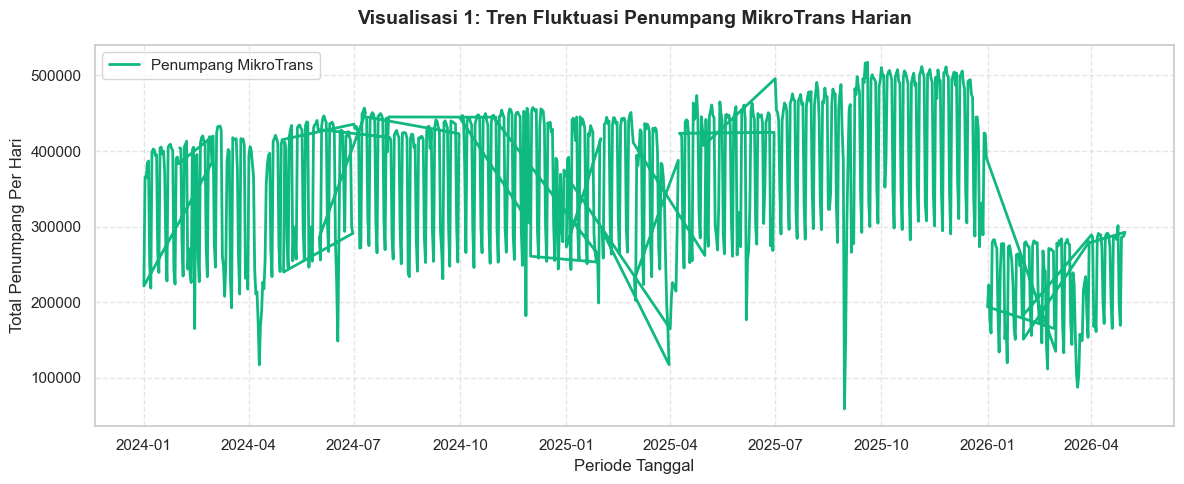

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df['tanggal'], df['jumlah_penumpang_per_hari'], color='#10b981', linewidth=2, label='Penumpang MikroTrans')
plt.title('Visualisasi 1: Tren Fluktuasi Penumpang MikroTrans Harian', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Periode Tanggal', fontsize=12)
plt.ylabel('Total Penumpang Per Hari', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('1_tren_penumpang_harian.png', dpi=300)
plt.show()

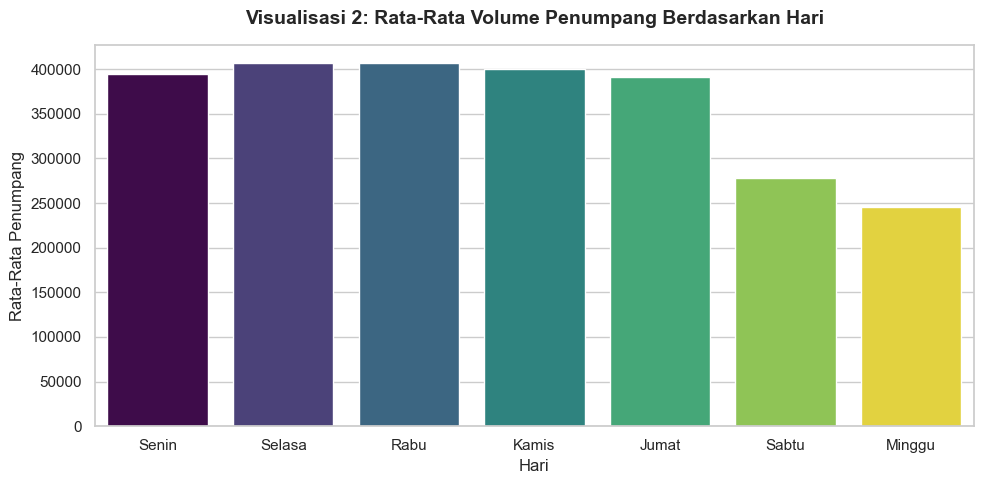

In [ ]:
# Mapping angka hari ke teks untuk grafik
nama_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
df_hari = df.groupby('hari')['jumlah_penumpang_per_hari'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_hari, x='hari', y='jumlah_penumpang_per_hari', hue='hari', palette='viridis', legend=False)
plt.xticks(ticks=range(7), labels=nama_hari)
plt.title('Visualisasi 2: Rata-Rata Volume Penumpang Berdasarkan Hari', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Rata-Rata Penumpang', fontsize=12)
plt.tight_layout()
plt.savefig('2_distribusi_hari.png', dpi=300)
plt.show()

In [ ]:
# Ekspansi data untuk jam (05.00 - 22.00)
df_expanded = df.sample(n=30000, replace=True, random_state=42).reset_index(drop=True)
np.random.seed(42)
df_expanded['jam'] = np.random.randint(5, 23, size=len(df_expanded))

# Logika Tombol IoT berdasarkan Jam Sibuk
def hitung_target_tombol_mikro(row):
    base_request = row['jumlah_penumpang_per_hari'] / 35000 
    if 7 <= row['jam'] <= 9 or 16 <= row['jam'] <= 19:
        factor = np.random.uniform(2.0, 3.5)
    else:
        factor = np.random.uniform(0.1, 0.6)
    hasil = int(base_request * factor)
    return max(1, min(hasil, 15))

df_expanded['estimasi_permintaan'] = df_expanded.apply(hitung_target_tombol_mikro, axis=1)

# Split Data
X = df_expanded[['hari', 'jam']]
y = df_expanded['estimasi_permintaan']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(" Tahap 3: Model AI Berhasil Dilatih!")

 Tahap 3: Model AI Berhasil Dilatih!


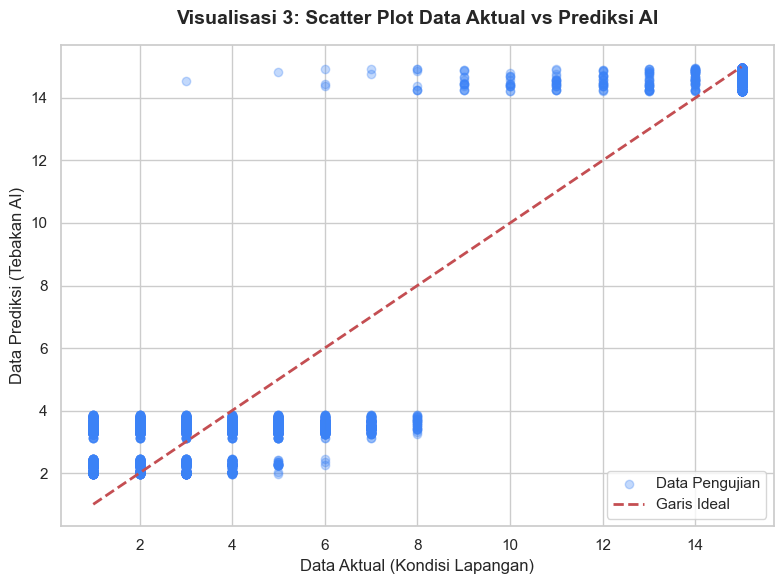

Mean Absolute Error (MAE) : 1.05 orang
Root Mean Squared Error (RMSE): 1.49 orang
R2 Score (Akurasi)         : 93.56%


In [7]:
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='#3b82f6', label='Data Pengujian')
# Garis linier ideal (jika tebakan AI 100% sempurna)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Garis Ideal')

plt.title('Visualisasi 3: Scatter Plot Data Aktual vs Prediksi AI', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Data Aktual (Kondisi Lapangan)', fontsize=12)
plt.ylabel('Data Prediksi (Tebakan AI)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('3_aktual_vs_prediksi.png', dpi=300)
plt.show()

# Print Metrik untuk laporan
print(f"Mean Absolute Error (MAE) : {mean_absolute_error(y_test, y_pred):.2f} orang")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} orang")
print(f"R2 Score (Akurasi)         : {r2_score(y_test, y_pred) * 100:.2f}%")

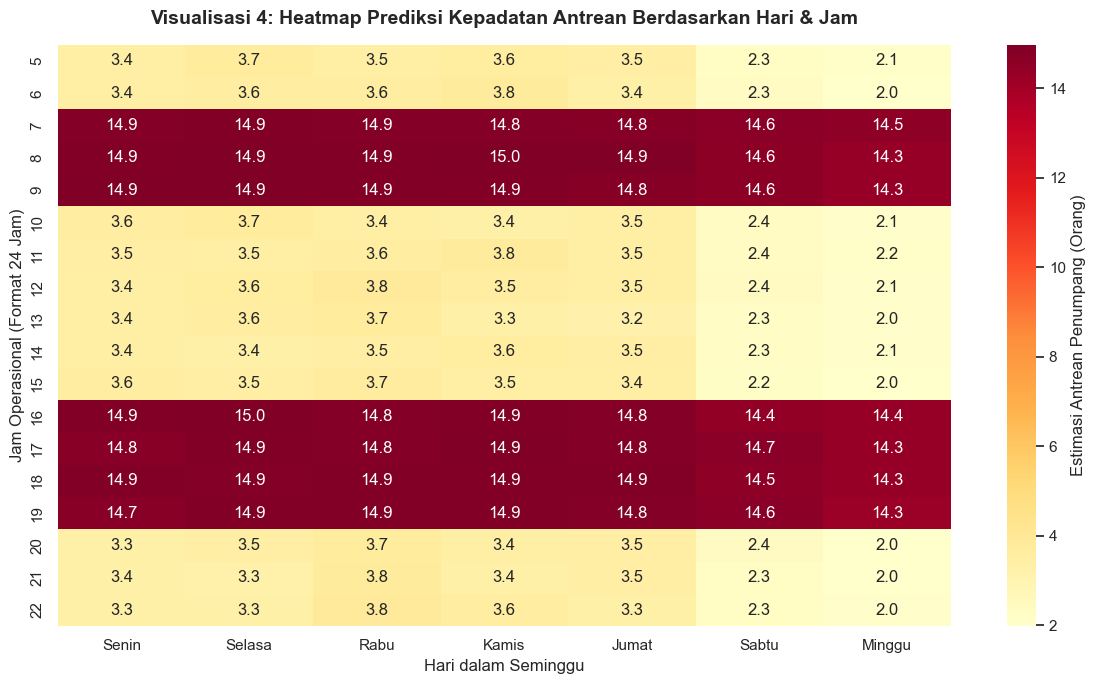

In [8]:
# Membuat pivot table untuk rata-rata prediksi di setiap kombinasi hari & jam
pivot_df = df_expanded.groupby(['hari', 'jam'])['estimasi_permintaan'].mean().unstack(level=0)
pivot_df.columns = nama_hari

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Estimasi Antrean Penumpang (Orang)'})
plt.title('Visualisasi 4: Heatmap Prediksi Kepadatan Antrean Berdasarkan Hari & Jam', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hari dalam Seminggu', fontsize=12)
plt.ylabel('Jam Operasional (Format 24 Jam)', fontsize=12)
plt.tight_layout()
plt.savefig('4_heatmap_kepadatan.png', dpi=300)
plt.show()

In [9]:
joblib.dump(model, 'model_jaklingko.joblib')
print(" SUCCESS!")

 SUCCESS!
